# Hypotheses prioritization

## Analysis objectives
The objective of this analysis is to understand which hypotheses are relevant to submit to the AB test.
For this, we will use the **hypotheses_us.csv** which contains nine hypotheses for increasing revenue, with the following columns:
- **Hypotheses** — brief descriptions of the hypotheses
- **Reach** — user reach, on a scale of one to ten
- **Impact** — impact on users, on a scale of one to ten
- **Confidence** — confidence in the hypothesis, on a scale of one to ten
- **Effort** — resources required to test a hypothesis, on a scale of one to ten. The higher the Effort value, the more resources are required for the test.

ICE and RICE scores will be calculated and compared to understand how user reach impacts hypothesis prioritization.

$$ICE = \frac{Impact \times Confidence}{Effort}$$

$$RICE = \frac{Reach \times Impact \times Confidence}{Effort}$$

ICE ignores reach entirely, meaning a hypothesis affecting 1 person scores the same as one affecting 1 million. On the other hand, RICE takes reach into consideration, which can significantly increase or decrease a hypothesis's priority compared to ICE.

In [278]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [279]:
# Loading the hypotheses data from a CSV file
df_hypotheses = pd.read_csv("../data/hypotheses_us.csv", sep=";")

In [280]:
# Checking the structure of the DataFrame
df_hypotheses.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Hypothesis  9 non-null      str  
 1   Reach       9 non-null      int64
 2   Impact      9 non-null      int64
 3   Confidence  9 non-null      int64
 4   Effort      9 non-null      int64
dtypes: int64(4), str(1)
memory usage: 492.0 bytes


In [281]:
# Generating unique IDs for each hypothesis
hypothesis_id = ["H" + str(i)
                 for i in range(1, len(df_hypotheses) + 1)]

# Inserting the generated IDs into the DataFrame
df_hypotheses.insert(0, "id", hypothesis_id)

In [282]:
# No maximum column width for full display of the DataFrame
pd.set_option('display.max_colwidth', None)

In [283]:
# Checking the full DataFrame
df_hypotheses.head(len(df_hypotheses))

,id,Hypothesis,Reach,Impact,Confidence,Effort
0,H1,Add two new channels for attracting traffic. This will bring 30% more users,3,10,8,6
1,H2,Launch your own delivery service. This will shorten delivery time,2,5,4,10
2,H3,Add product recommendation blocks to the store's site. This will increase conversion and average purchase size,8,3,7,3
3,H4,Change the category structure. This will increase conversion since users will find the products they want more quickly,8,3,3,8
4,H5,Change the background color on the main page. This will increase user engagement,3,1,1,1
5,H6,Add a customer review page. This will increase the number of orders,3,2,2,3
6,H7,Show banners with current offers and sales on the main page. This will boost conversion,5,3,8,3
7,H8,Add a subscription form to all the main pages. This will help you compile a mailing list,10,7,8,5
8,H9,Launch a promotion that gives users discounts on their birthdays,1,9,9,5


## 01 - ICE score
Hypotheses are ranked by ICE score to identify the best candidates for A/B testing based on expected impact and confidence, without considering how many users each hypothesis will reach.

In [284]:
# Calculating the ICE score for each hypothesis
df_hypotheses['ICE'] = df_hypotheses['Impact'] * \
    df_hypotheses['Confidence'] / df_hypotheses['Effort']

In [285]:
# Saving the ICE scores in a new DataFrame sorted by ICE score
ice_scores = df_hypotheses[['id', 'ICE']].sort_values(
    by='ICE', ascending=False).reset_index(drop=True)

In [286]:
# Displaying the hypotheses sorted by ICE score
ice_scores

,id,ICE
0,H9,16.200000
1,H1,13.333333
2,H8,11.200000
3,H7,8.000000
4,H3,7.000000
5,H2,2.000000
6,H6,1.333333
7,H4,1.125000
8,H5,1.000000


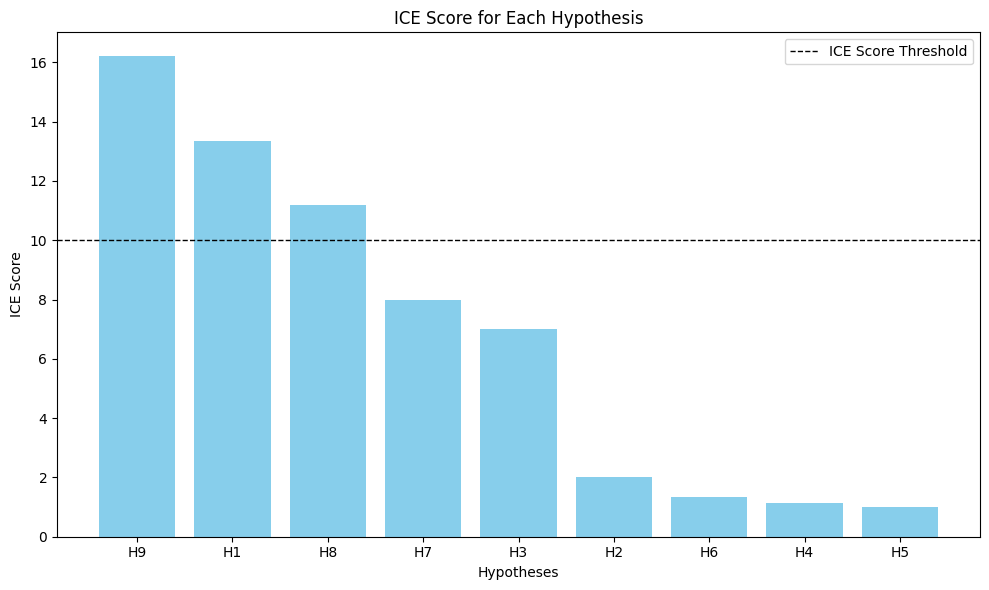

In [287]:
# Visualizing the ICE scores using a bar chart
plt.figure(figsize=(10, 6))
plt.bar(ice_scores["id"],
        ice_scores["ICE"], color="skyblue")
plt.axhline(y=10, color='black', linestyle='--',
            linewidth=1, label='ICE Score Threshold')
plt.xlabel("Hypotheses")
plt.ylabel("ICE Score")
plt.title("ICE Score for Each Hypothesis")
plt.legend()
plt.tight_layout()
plt.show()

### ICE - observations
- ICE absolute values can vary between 0.1 (min) and 100 (max).
- ICE relative values vary between 1.0 (min) and 16.2 (max).
- Hypotheses H9, H1 and H8 should be the ones to be tested if we consider ICE, as they are the top 3 scores higher than 10.

## 02 - RICE score
By adding Reach to the formula, RICE reveals how user reach affects prioritization, showing whether high-impact hypotheses are actually worth testing at scale.

In [288]:
# Calculating the RICE score for each hypothesis
df_hypotheses['RICE'] = df_hypotheses['Reach'] * \
    df_hypotheses['Impact'] * \
    df_hypotheses['Confidence'] / df_hypotheses['Effort']

In [289]:
# Saving the RICE scores in a new DataFrame sorted by RICE score
rice_scores = df_hypotheses[['id', 'RICE', 'Reach']].sort_values(
    by=['RICE', 'Reach'], ascending=False).reset_index(drop=True)

In [290]:
# Displaying the hypotheses sorted by RICE score
rice_scores

,id,RICE,Reach
0,H8,112.0,10
1,H3,56.0,8
2,H7,40.0,5
3,H1,40.0,3
4,H9,16.2,1
5,H4,9.0,8
6,H6,4.0,3
7,H2,4.0,2
8,H5,3.0,3


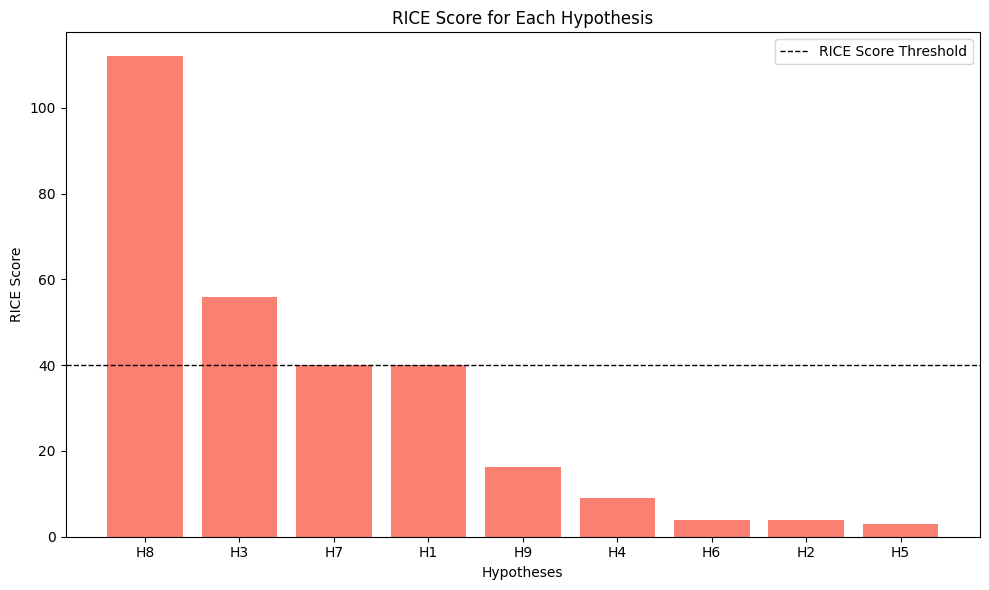

In [291]:
# Visualizing the RICE scores using a bar chart
plt.figure(figsize=(10, 6))
plt.bar(rice_scores["id"],
        rice_scores["RICE"], color="salmon")
plt.axhline(y=40, color='black', linestyle='--',
            linewidth=1, label='RICE Score Threshold')
plt.xlabel("Hypotheses")
plt.ylabel("RICE Score")
plt.title("RICE Score for Each Hypothesis")
plt.legend()
plt.tight_layout()
plt.show()

### RICE - observations
- RICE absolute values can vary between 0.1 (min) and 1000 (max).
- RICE relative values vary between 3.0 (min) and 112.0 (max).
- Hypothesis H8 is the top priority to test if we consider RICE, as it is the top score having the double of points of the second place.
- Hypothesis H3, H1 and H7 should also be tested as they place the next top performers with 56 and 40 points, more than the double of 5th position with 16.2 points.

## 03 - ICE vs RICE

In [292]:
# Sort by RICE then Reach to apply tiebreaker
df_sorted_rice = df_hypotheses.sort_values(['RICE', 'Reach'], ascending=False)

In [293]:
# Creating score ranks for both ICE and RICE scores
ranks = pd.DataFrame({
    'id': df_hypotheses['id'],
    'ICE_rank': df_hypotheses['ICE'].rank(ascending=False, method='first'),
    'RICE_rank': df_sorted_rice['RICE'].rank(ascending=False, method='first')
})

In [294]:
# Displaying the ranks
ranks

,id,ICE_rank,RICE_rank
0,H1,2.0,4.0
1,H2,6.0,8.0
2,H3,5.0,2.0
3,H4,8.0,6.0
4,H5,9.0,9.0
5,H6,7.0,7.0
6,H7,4.0,3.0
7,H8,3.0,1.0
8,H9,1.0,5.0


In [295]:
# Legend entries for the slope chart — must run before the chart cell
# Line2D creates a custom legend handle without needing to plot anything
legend_elements = [
    Line2D([0], [0], color='green', label='Moved up in RICE'),
    Line2D([0], [0], color='red',   label='Moved down in RICE'),
    Line2D([0], [0], color='gray',  label='No change')
]

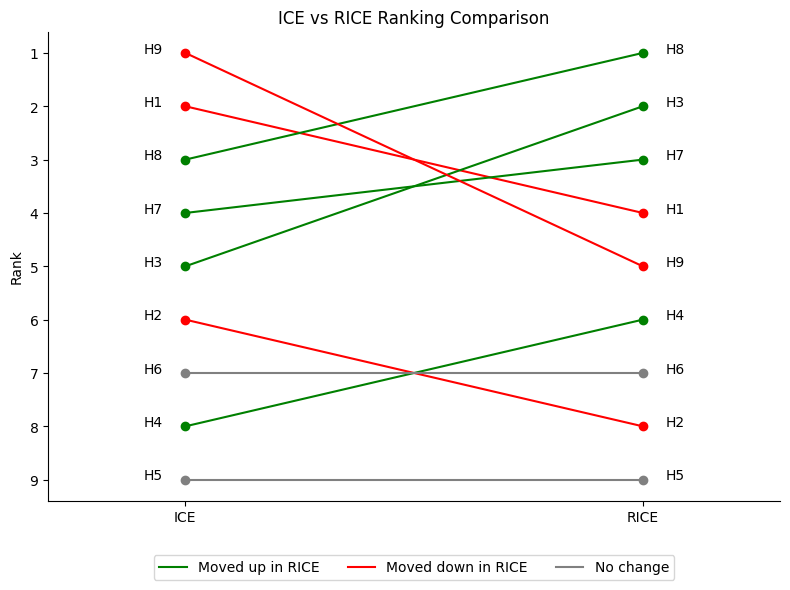

In [296]:
# Slope chart: each hypothesis is a line connecting its ICE rank (left) to its RICE rank (right)
fig, ax = plt.subplots(figsize=(8, 6))
x = [1, 2]  # fixed x positions — 1 for ICE column, 2 for RICE column

for _, row in ranks.iterrows():
    # Assign color based on whether rank improved, worsened, or stayed the same in RICE
    # Lower rank number = better position, so RICE_rank < ICE_rank means moved up
    if row['RICE_rank'] < row['ICE_rank']:
        color = 'green'
    elif row['RICE_rank'] > row['ICE_rank']:
        color = 'red'
    else:
        color = 'gray'

    # Draw line with dots from ICE rank to RICE rank for this hypothesis
    ax.plot(x, [row['ICE_rank'], row['RICE_rank']], 'o-', color=color)
    # Label on the left side of the ICE column
    ax.text(x[0] - 0.05, row['ICE_rank'], row['id'], ha='right')
    # Label on the right side of the RICE column
    ax.text(x[1] + 0.05, row['RICE_rank'], row['id'], ha='left')

# Invert so rank 1 appears at the top (best position)
ax.invert_yaxis()

# Replace numeric x-axis ticks with framework names
ax.set_xticks([1, 2])
ax.set_xticklabels(['ICE', 'RICE'])
ax.set_ylabel('Rank')
ax.set_title('ICE vs RICE Ranking Comparison')
# Extend x limits to prevent labels from being clipped at the chart edges
ax.set_xlim(0.7, 2.3)
# Place legend below the chart in a single row to avoid overlapping the lines
ax.legend(handles=legend_elements,
          bbox_to_anchor=(0.5, -0.1),
          loc='upper center',
          ncols=3)

# Remove top and right borders for a cleaner look (standard for slope charts)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Force y-axis to show only integer rank values
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

### Conclusion

Adding Reach to the scoring formula significantly reshuffled the hypothesis rankings, revealing that high impact alone is not sufficient to justify prioritizing a hypothesis for A/B testing.

The most notable changes between ICE and RICE:

- **H9** dropped from rank 1 to rank 5 — it scored highest on ICE due to strong Impact and Confidence, but its Reach of 1 means it would affect very few users, making it a poor candidate for a large-scale test.
- **H8** moved up from rank 3 to rank 1 — with the highest Reach score (10) and solid Impact and Confidence, it represents the hypothesis with the greatest potential business impact.
- **H3** moved up from rank 5 to rank 2 — high Reach (8) compensated for its moderate Impact, pushing it ahead of hypotheses that looked stronger under ICE.
- **H6** and **H5** remained unchanged, as their Reach did not alter their relative position.

**Recommendation:** RICE is the more appropriate framework for this analysis, as it accounts for user reach and better reflects the real-world impact 